## Day 3 – Implementation

*Focus: structured, traceable execution*

In [8]:
# Standalone setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.fft import fft, fftfreq

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)
if isinstance(smi_1min.columns, pd.MultiIndex):
    smi_1min.columns = smi_1min.columns.get_level_values(0)

price = smi_1min['Close'].dropna().values.astype(float)
time_index = smi_1min['Close'].dropna().index

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_28372/1091125325.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)


In [9]:
# Generate high-resolution reference signal
# The original 1-minute data serves as the continuous approximation
reference_signal = price.copy()
N = len(reference_signal)
T_s = 60  # seconds
f_s = 1 / T_s
time_seconds = np.arange(N) * T_s

print(f"Reference signal: {N} samples")
print(f"Duration: {N * T_s / 3600:.1f} hours ({N * T_s / 3600 / 24:.1f} trading days)")

Reference signal: 3183 samples
Duration: 53.0 hours (2.2 trading days)


In [10]:
# Implement systematic downsampling at defined rates
downsample_factors = [1, 2, 5, 15, 60]
labels = ['D=1 (1 min, baseline)', 'D=2 (2 min, at Nyquist)',
          'D=5 (5 min, below)', 'D=15 (15 min, well below)',
          'D=60 (1 hour, severe)']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

sampled_signals = {}
for D, label in zip(downsample_factors, labels):
    sampled = reference_signal[::D]
    sampled_time = time_seconds[::D]
    effective_fs = f_s / D
    nyquist = effective_fs / 2
    sampled_signals[label] = {
        'signal': sampled,
        'time': sampled_time,
        'factor': D,
        'f_s': effective_fs,
        'f_nyquist': nyquist
    }
    print(f"{label}: {len(sampled)} samples, f_s={effective_fs:.6f} Hz, f_Nyq={nyquist:.6f} Hz")

D=1 (1 min, baseline): 3183 samples, f_s=0.016667 Hz, f_Nyq=0.008333 Hz
D=2 (2 min, at Nyquist): 1592 samples, f_s=0.008333 Hz, f_Nyq=0.004167 Hz
D=5 (5 min, below): 637 samples, f_s=0.003333 Hz, f_Nyq=0.001667 Hz
D=15 (15 min, well below): 213 samples, f_s=0.001111 Hz, f_Nyq=0.000556 Hz
D=60 (1 hour, severe): 54 samples, f_s=0.000278 Hz, f_Nyq=0.000139 Hz


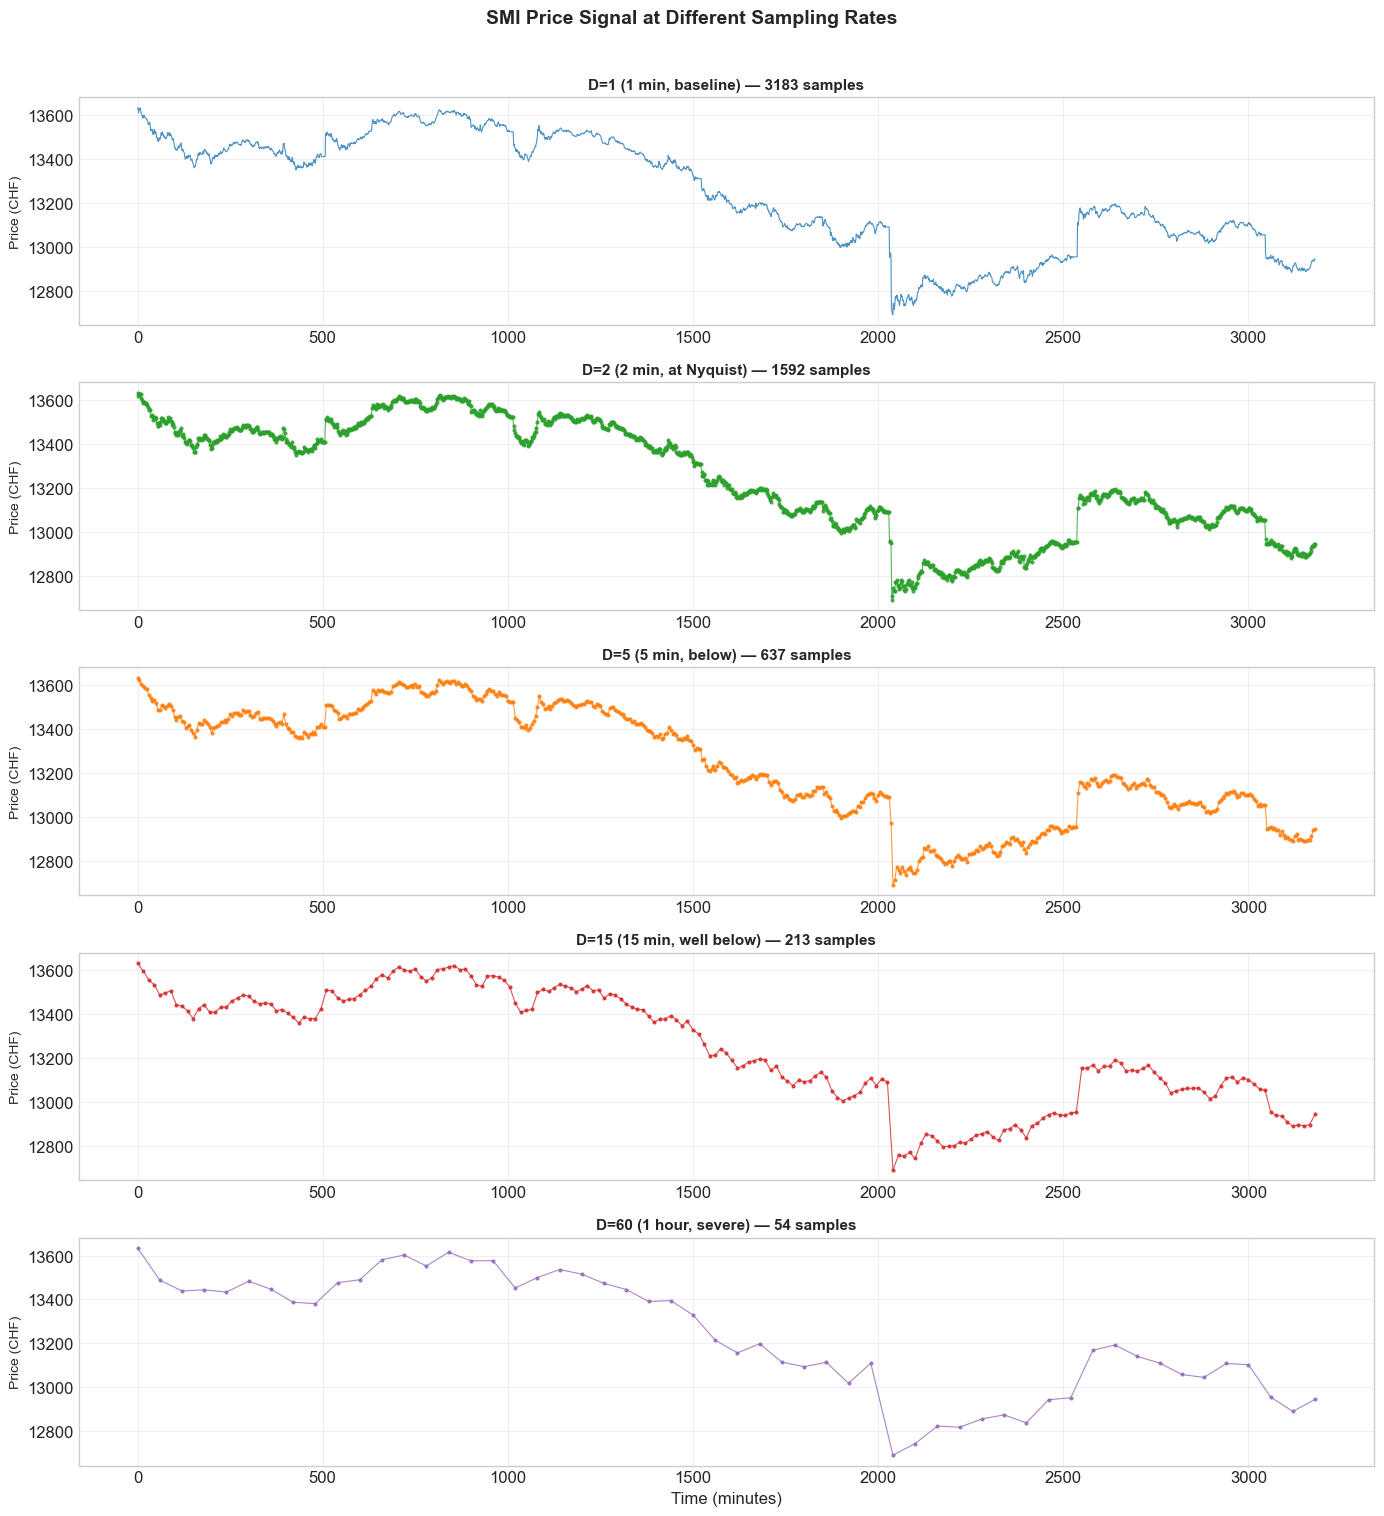

In [11]:
# Time-domain visualization of sampled signals
fig, axes = plt.subplots(len(downsample_factors), 1, figsize=(14, 3*len(downsample_factors)))

for i, (label, data) in enumerate(sampled_signals.items()):
    t_min = data['time'] / 60  # convert to minutes
    axes[i].plot(t_min, data['signal'], color=colors[i], linewidth=0.8,
                 marker='o' if data['factor'] > 1 else '', markersize=2, alpha=0.8)
    axes[i].set_ylabel('Price (CHF)', fontsize=10)
    axes[i].set_title(f"{label} — {len(data['signal'])} samples", fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (minutes)', fontsize=12)
plt.suptitle('SMI Price Signal at Different Sampling Rates', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

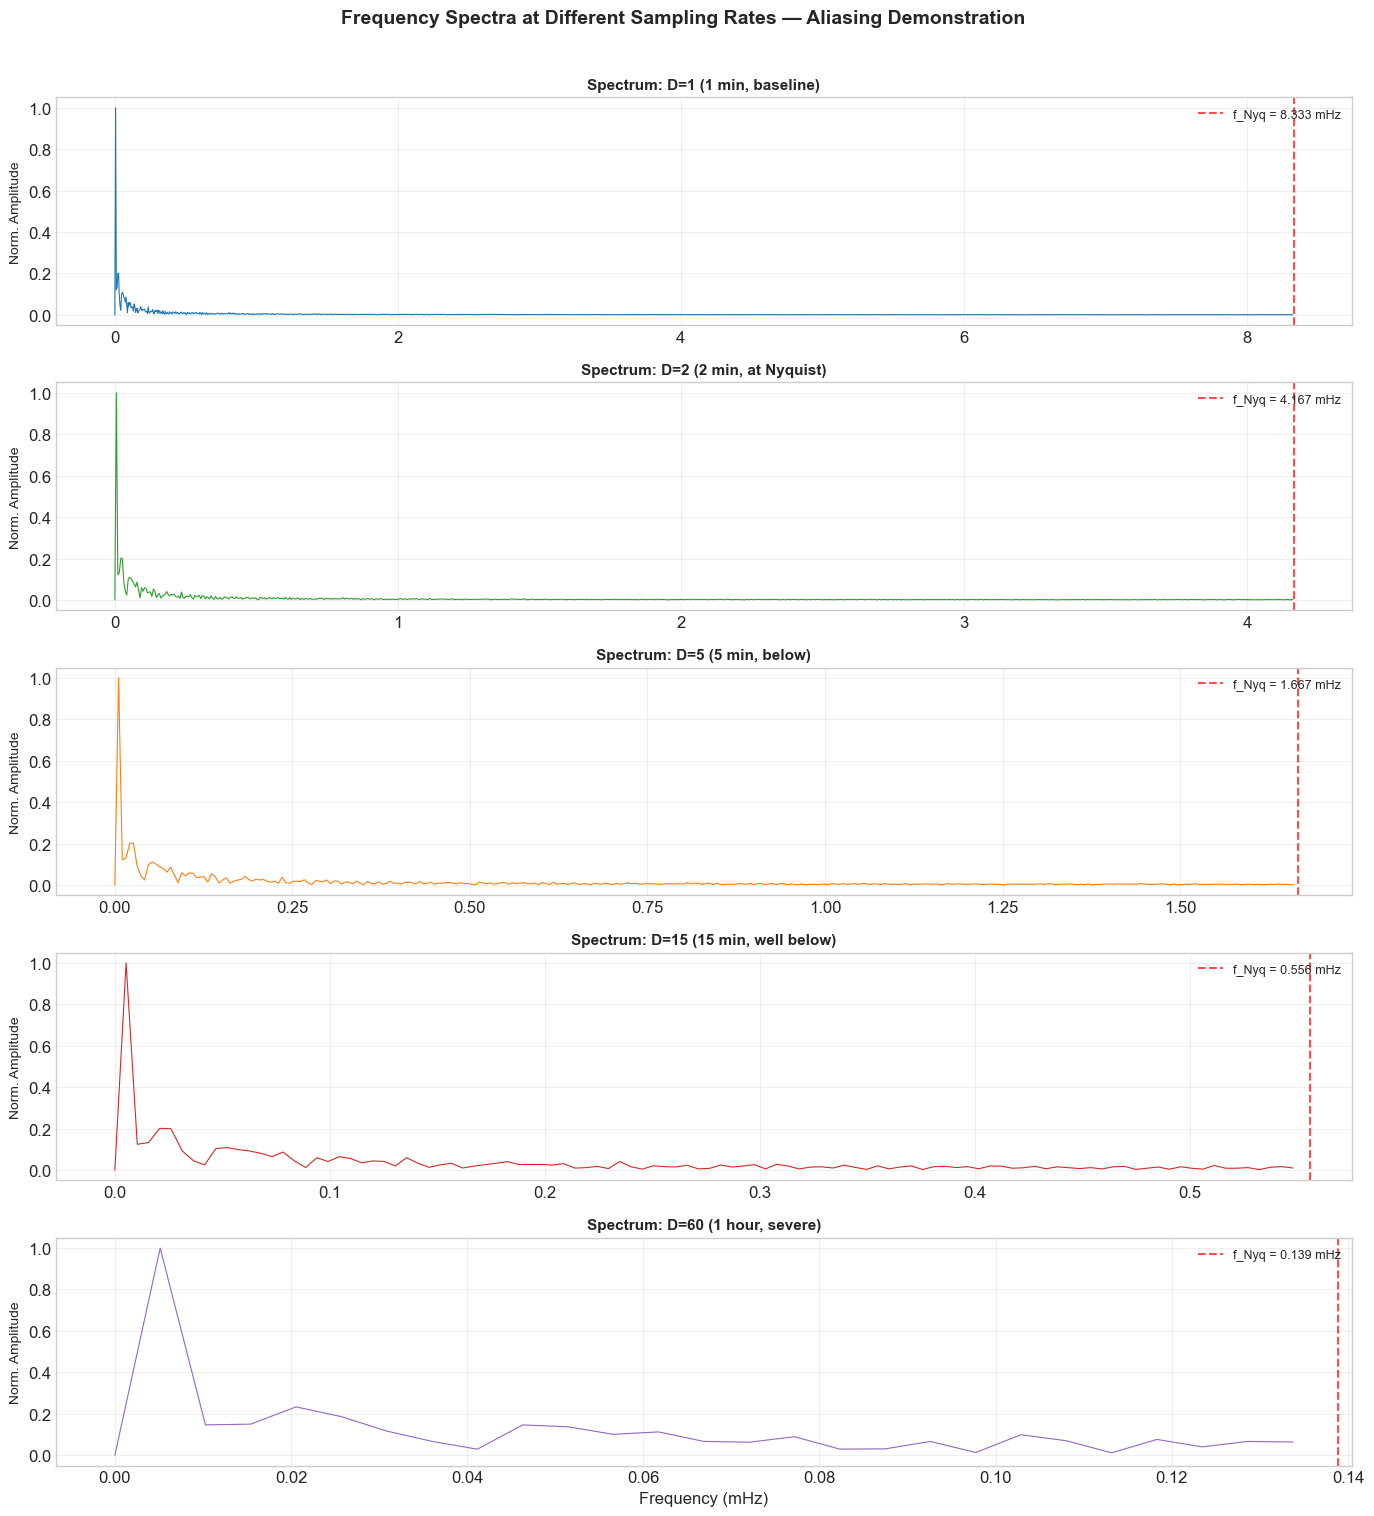

In [12]:
# Frequency-domain analysis: demonstrate aliasing
fig, axes = plt.subplots(len(downsample_factors), 1, figsize=(14, 3*len(downsample_factors)))

for i, (label, data) in enumerate(sampled_signals.items()):
    sig = data['signal'] - np.mean(data['signal'])  # remove DC
    n = len(sig)
    spectrum = np.abs(fft(sig))[:n//2]
    freqs = fftfreq(n, d=1/data['f_s'])[:n//2]
    
    axes[i].plot(freqs * 1000, spectrum / np.max(spectrum), color=colors[i], linewidth=0.8)
    axes[i].axvline(x=data['f_nyquist']*1000, color='red', linestyle='--', alpha=0.7,
                    label=f'f_Nyq = {data["f_nyquist"]*1000:.3f} mHz')
    axes[i].set_ylabel('Norm. Amplitude', fontsize=10)
    axes[i].set_title(f"Spectrum: {label}", fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9, loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency (mHz)', fontsize=12)
plt.suptitle('Frequency Spectra at Different Sampling Rates — Aliasing Demonstration',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

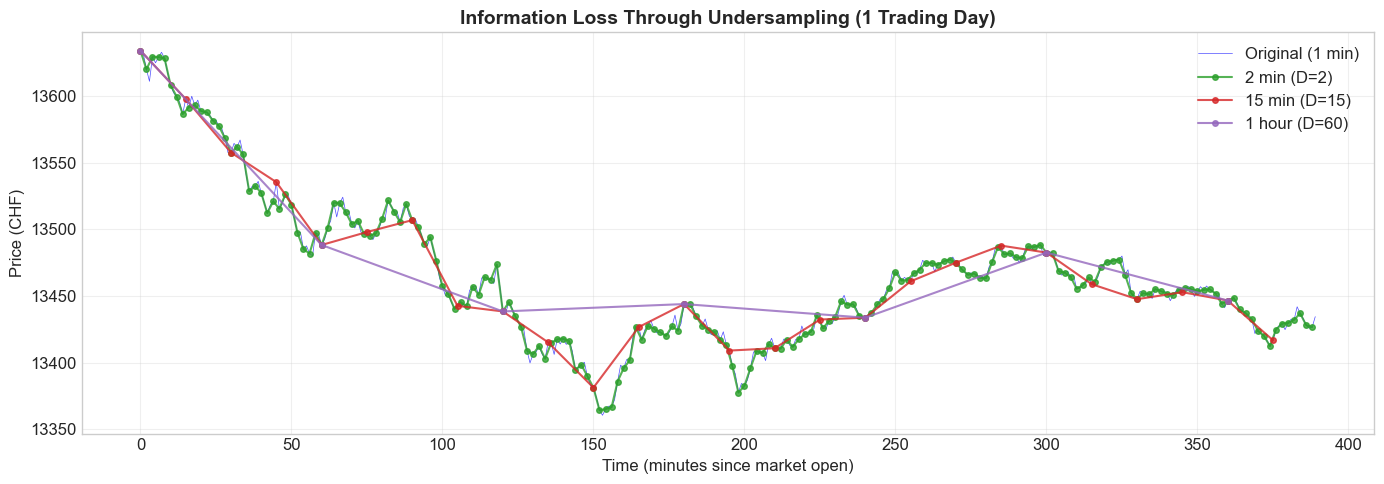

In [13]:
# Detail comparison: overlay original vs severely undersampled (1 trading day)
n_day = min(390, N)  # approximately one trading day
ref_day = reference_signal[:n_day]
t_day = time_seconds[:n_day] / 60

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_day, ref_day, 'b-', linewidth=0.5, alpha=0.7, label='Original (1 min)')

for D, color, lbl in [(2, '#2ca02c', '2 min'), (15, '#d62728', '15 min'), (60, '#9467bd', '1 hour')]:
    ds = ref_day[::D]
    t_ds = t_day[::D]
    ax.plot(t_ds, ds, '-o', color=color, linewidth=1.5, markersize=4, label=f'{lbl} (D={D})', alpha=0.8)

ax.set_xlabel('Time (minutes since market open)', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title('Information Loss Through Undersampling (1 Trading Day)', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()